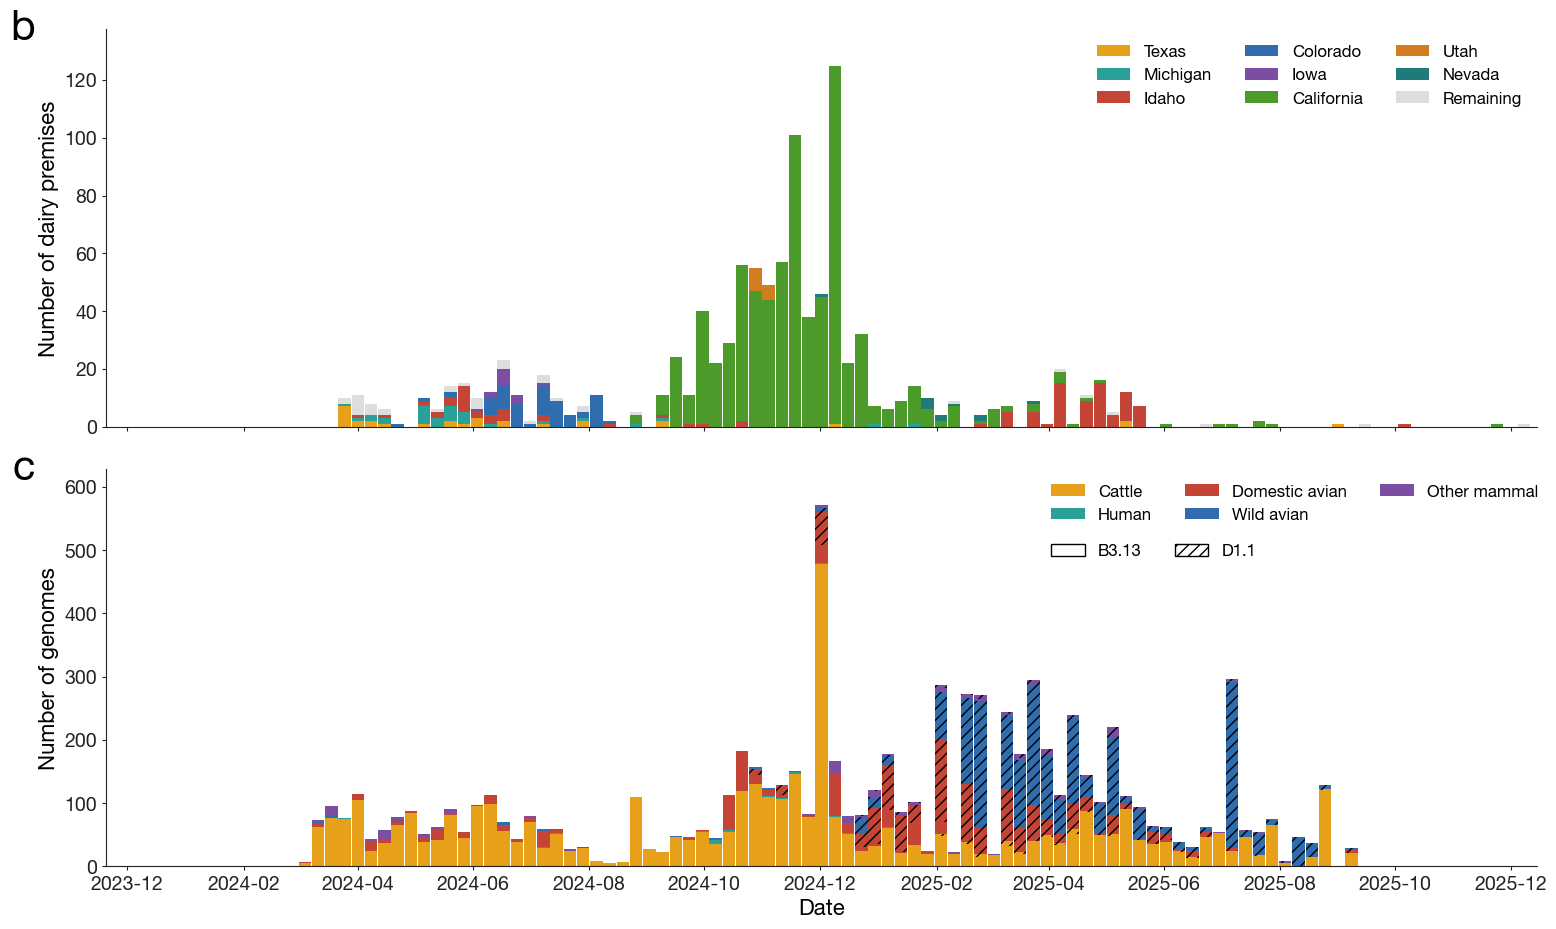

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# -----------------------------
# Inputs
# -----------------------------
seq_path = "../data/raw/B3.13_D1.1_SEP19_seq_metadata.csv"
outbreak_path = "../data/raw/USDA_h5n1_cattle_poultry_outbreaks_2024-01-01_to_2025-12-21.csv"

min_outbreaks = 10          # states with >= this many outbreaks are shown; others -> "Remaining"
width_days = 6.5            # bar width in "days" for weekly bins
hatch_pattern = "///"       # hatch used for D1.1
hatch_edgecolor = "#222222" # hatch line color (kept dark for readability)

# -----------------------------
# Palette
# -----------------------------
PALETTE_NAME = "wkw_9"

def get_palettes(name="wkw_9"):
    """
    9 total hues. Reuses bucket colors as part of the 9-color state palette.
    Returns:
      bucket_colors, state_palette, remaining_color, hatch_edgecolor
    """
    if name == "wkw_9":
        bucket_colors = {
            "Human": "#2AA198",            # teal
            "Cattle": "#E6A01A",           # amber
            "Domestic avian":  "#C44536",  # muted red
            "Wild avian":  "#2F6DAE",      # steel blue
            "Other mammal":  "#7B4DA3",    # violet
            "Unknown metadata": "#C9C9C9", # light grey
        }

        state_palette = [
            bucket_colors["Cattle"],
            bucket_colors["Human"],
            bucket_colors["Domestic avian"],
            bucket_colors["Wild avian"],
            bucket_colors["Other mammal"],
            "#4C9A2A",  # olive green
            "#D17C1F",  # burnt orange
            "#1F7A7A",  # deep teal
            "#8A5A44",  # brown
        ]

        remaining_color = "#DDDDDD"
        hatch_edgecolor = "white"
    else:
        raise ValueError(f"Unknown palette: {name}")

    return bucket_colors, state_palette, remaining_color, hatch_edgecolor


bucket_colors, state_palette, remaining_color, hatch_edgecolor = get_palettes(PALETTE_NAME)
hatch_edgecolor = "black"

# -----------------------------
# Helper: publication-ish axes
# -----------------------------
def publication_axes(ax):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#222222")
    ax.spines["bottom"].set_color("#222222")
    ax.tick_params(axis="both", colors="#222222", length=3, width=0.8)
    ax.grid(False)

# -----------------------------
# Load data
# -----------------------------
seq = pd.read_csv(seq_path)
outbreaks = pd.read_csv(outbreak_path)

# -----------------------------
# Sequences: dates + weekly bins (weeks start Monday)
# -----------------------------
seq["collection_date"] = pd.to_datetime(seq["collection_date"], errors="coerce")
seq["release_date"] = pd.to_datetime(seq["release_date"], errors="coerce")
seq["plot_date"] = seq["collection_date"].fillna(seq["release_date"])
seq = seq.dropna(subset=["plot_date"]).copy()

# Weeks that START Monday: use week-ending Sunday periods, then take start_time.
seq["week"] = seq["plot_date"].dt.to_period("W-SUN").dt.start_time
seq = seq[seq["genotype"].isin(["B3.13", "D1.1"])].copy()

def bucket_row(row):
    ht = str(row.get("host_type", "")).strip().lower()
    h  = str(row.get("host", "")).strip().lower()

    if ("human" in ht) or ("human" in h):
        return "Human"
    if ("cattle" in ht) or ("bovine" in ht) or ("dairy" in h) or ("cow" in h):
        return "Cattle"
    if ("domestic_avian" in ht) or ("domestic_avian" in h):
        return "Domestic avian"
    if ("wild_avian" in ht) or ("wild_avian" in h):
        return "Wild avian"
    if ("feline" in ht) or ("feline" in h) or ("mammal" in ht) or ("mammal" in h):
        return "Other mammal"
    return None

seq["bucket"] = seq.apply(bucket_row, axis=1)
seq = seq.dropna(subset=["bucket"]).copy()

bucket_order = ["Cattle", "Human", "Domestic avian", "Wild avian", "Other mammal"]

counts = (
    seq.groupby(["week", "bucket", "genotype"])
       .size()
       .rename("n")
       .reset_index()
)

all_weeks = pd.date_range(counts["week"].min(), counts["week"].max(), freq="W-MON")
mi = pd.MultiIndex.from_product(
    [all_weeks, bucket_order, ["B3.13", "D1.1"]],
    names=["week", "bucket", "genotype"]
)

counts_full = (
    counts.set_index(["week", "bucket", "genotype"])["n"]
          .reindex(mi, fill_value=0)
          .reset_index()
)

b313 = (
    counts_full[counts_full["genotype"] == "B3.13"]
    .pivot(index="week", columns="bucket", values="n")
    .reindex(index=all_weeks, columns=bucket_order, fill_value=0)
)
d11 = (
    counts_full[counts_full["genotype"] == "D1.1"]
    .pivot(index="week", columns="bucket", values="n")
    .reindex(index=all_weeks, columns=bucket_order, fill_value=0)
)

# -----------------------------
# Outbreaks: weekly bins (weeks start Monday) + collapse states
# -----------------------------
outbreaks["confirmation_date"] = pd.to_datetime(
    outbreaks["Confirmation Date"],
    format="%d-%b-%y",
    errors="coerce"
)
outbreaks = outbreaks.dropna(subset=["confirmation_date"]).copy()
outbreaks["Species"] = outbreaks["Species"].astype(str).str.strip()
outbreaks = outbreaks[outbreaks["Species"].str.lower() == "cattle"].copy()

outbreaks["State"] = outbreaks["State"].astype(str).str.strip()
outbreaks["week"] = outbreaks["confirmation_date"].dt.to_period("W-SUN").dt.start_time

# collapse to Remaining based on total counts
state_totals = outbreaks["State"].value_counts()
keep_states = state_totals[state_totals >= min_outbreaks].index.tolist()
outbreaks["State_collapsed"] = outbreaks["State"].where(outbreaks["State"].isin(keep_states), "Remaining")

# -------------------------------------------------------
# State order + colors by DATAFRAME appearance (not plot):
# first occurrence when sorted by confirmation_date,
# and keep "Remaining" last
# -------------------------------------------------------
tmp = outbreaks.dropna(subset=["confirmation_date"]).copy()
tmp = tmp.sort_values("confirmation_date", kind="mergesort")  # stable

seen = set()
state_cols = []
for st in tmp["State_collapsed"].tolist():
    if st not in seen and st != "Remaining":
        state_cols.append(st)
        seen.add(st)

if (tmp["State_collapsed"] == "Remaining").any():
    state_cols.append("Remaining")

state_color_map = {}
k = 0
for st in state_cols:
    if st == "Remaining":
        state_color_map[st] = remaining_color
    else:
        state_color_map[st] = state_palette[k % len(state_palette)]
        k += 1

# -----------------------------
# Outbreak weekly counts
# -----------------------------
out_counts_raw = (
    outbreaks.groupby(["week", "State_collapsed"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

out_weeks = pd.date_range(out_counts_raw.index.min(), out_counts_raw.index.max(), freq="W-MON")
out_counts = out_counts_raw.reindex(out_weeks, fill_value=0)

# enforce dataframe-derived column order
out_counts = out_counts.reindex(columns=state_cols, fill_value=0)

# -----------------------------
# Shared x-limits
# -----------------------------
xmin = min(all_weeks.min(), out_weeks.min())
xmax = max(all_weeks.max(), out_weeks.max()) + pd.Timedelta(days=7)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12*1.3, 7.2*1.3), sharex=True)

ax_out = axes[0]   # outbreaks on top
ax_gen = axes[1]   # genomes on bottom

# ---- Panel: genomes (B3.13 solid; D1.1 hatched)
ax = ax_gen
publication_axes(ax)

bottom = np.zeros(len(all_weeks), dtype=float)
for b in bucket_order:
    ax.bar(
        all_weeks,
        b313[b].values,
        bottom=bottom,
        width=width_days,
        align="center",
        color=bucket_colors[b],
        linewidth=0
    )
    bottom = bottom + b313[b].values

    ax.bar(
        all_weeks,
        d11[b].values,
        bottom=bottom,
        width=width_days,
        align="center",
        color=bucket_colors[b],
        hatch=hatch_pattern,
        edgecolor=hatch_edgecolor,
        linewidth=0
    )
    bottom = bottom + d11[b].values

ax.set_ylabel("Number of genomes", fontsize=16)
ax.set_xlim(xmin, xmax)
ax.set_ylim(0, max(bottom.max(), 1) * 1.10)
ax.set_xlabel("Date", fontsize=16)
ax.tick_params(axis="x", rotation=0, labelsize=14)
ax.tick_params(axis="y", labelsize=14)

bucket_handles = [Patch(facecolor=bucket_colors[b], edgecolor="none", label=b) for b in bucket_order]
geno_handles = [
    Patch(facecolor="white", edgecolor=hatch_edgecolor, label="B3.13"),
    Patch(facecolor="white", edgecolor=hatch_edgecolor, hatch=hatch_pattern, label="D1.1"),
]

xloc = 0.65
leg1 = ax.legend(handles=bucket_handles, frameon=False, ncol=3, loc="upper left",
                 bbox_to_anchor=(xloc, 1), fontsize=12)
ax.add_artist(leg1)
ax.legend(handles=geno_handles, frameon=False, ncol=2, loc="upper left",
          bbox_to_anchor=(xloc, .85), fontsize=12)

# ---- Panel: outbreaks (stacked by state) — colors/order from dataframe appearance
ax2 = ax_out
publication_axes(ax2)

bottom2 = np.zeros(len(out_weeks), dtype=float)
for st in state_cols:
    vals = out_counts[st].values
    if vals.sum() == 0:
        continue
    ax2.bar(
        out_weeks,
        vals,
        bottom=bottom2,
        width=width_days,
        align="center",
        color=state_color_map[st],
        linewidth=0,
        label=st
    )
    bottom2 = bottom2 + vals

ax2.set_ylabel("Number of dairy premises", fontsize=16)
ax2.set_xlim(xmin, xmax)
ax2.set_ylim(0, max(bottom2.max(), 1) * 1.10)
ax2.tick_params(axis="y", labelsize=14)

# Legend in dataframe-derived order (Remaining last)
legend_handles = [
    Patch(facecolor=state_color_map[st], edgecolor="none", label=st)
    for st in state_cols
    if out_counts[st].to_numpy().sum() > 0
]
ax2.legend(handles=legend_handles, frameon=False, ncol=3, fontsize=12, loc="upper right")

# -----------------------------
# Shared x formatting
# -----------------------------
labels = ["b", "c"]
for i, a in enumerate(axes):
    a.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    a.tick_params(axis="x", rotation=0)
    a.text(-0.05, 1.05, labels[i], transform=a.transAxes,
           fontsize=30, fontweight="bold", va="top", ha="right")

plt.tight_layout()
plt.savefig("../figures/fig1.barplots.png", dpi=300)
plt.savefig("../figures/fig1.barplots.pdf", dpi=300)
plt.show()
